Error loading image: simple_images/.ipynb_checkpoints
Iteration 1, loss = 0.77988705
Iteration 2, loss = 2.99124601
Iteration 3, loss = 0.72687260
Iteration 4, loss = 0.67076434
Iteration 5, loss = 0.71002409
Iteration 6, loss = 0.65809411
Iteration 7, loss = 0.65298124
Iteration 8, loss = 0.63886643
Iteration 9, loss = 0.60104922
Iteration 10, loss = 0.58563666
Iteration 11, loss = 0.56743482
Iteration 12, loss = 0.55091559
Iteration 13, loss = 0.53126038
Iteration 14, loss = 0.51234903
Iteration 15, loss = 0.49586334
Iteration 16, loss = 0.47907337
Iteration 17, loss = 0.46286617
Iteration 18, loss = 0.44787831
Iteration 19, loss = 0.43376267
Iteration 20, loss = 0.42074101
Iteration 21, loss = 0.40958698
Iteration 22, loss = 0.39905597
Iteration 23, loss = 0.38827010
Iteration 24, loss = 0.38013559
Iteration 25, loss = 0.37143945
Iteration 26, loss = 0.36190348
Iteration 27, loss = 0.35362021
Iteration 28, loss = 0.34762371
Iteration 29, loss = 0.33811909
Iteration 30, loss = 0.3308

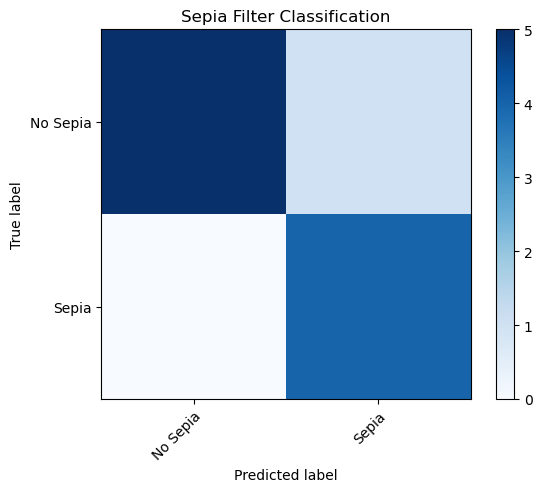

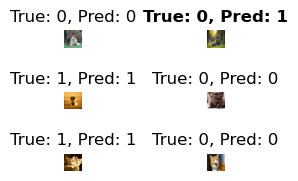

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neural_network
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from PIL import Image


def load_images_from_folder(folder, label, image_size=(64, 64)):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        try:
            img = Image.open(img_path).convert('RGB') 
            img = img.resize(image_size)  
            img_array = np.array(img)
            images.append(img_array)
            labels.append(label)
        except:
            print(f"Error loading image: {img_path}")
    return images, labels

#combin imaginile si le amestec aleator
def prepare_dataset(folder_no_filter, folder_sepia):
    no_filter_images, no_filter_labels = load_images_from_folder(folder_no_filter, 0)
    sepia_images, sepia_labels = load_images_from_folder(folder_sepia, 1)

    images = no_filter_images + sepia_images
    labels = no_filter_labels + sepia_labels

    images = np.array(images)
    labels = np.array(labels)


    indices = np.random.permutation(len(images))
    images = images[indices]
    labels = labels[indices]

    return images, labels


def flatten_and_normalize(images):
    #tranform imaginea intr-un vector si normalizez valorile intre 0 si 1
    images_flatten = [img.flatten() for img in images]
    images_flatten = np.array(images_flatten, dtype=np.float32)
    images_flatten /= 255.0 
    return images_flatten


def split_data(inputs, outputs, train_ratio=0.8):
    split_index = int(len(inputs) * train_ratio)
    train_inputs = inputs[:split_index]
    train_outputs = outputs[:split_index]
    test_inputs = inputs[split_index:]
    test_outputs = outputs[split_index:]
    return train_inputs, train_outputs, test_inputs, test_outputs


def eval_classification(true_labels, predicted_labels):
    acc = accuracy_score(true_labels, predicted_labels)
    prec = precision_score(true_labels, predicted_labels)
    rec = recall_score(true_labels, predicted_labels)
    cm = confusion_matrix(true_labels, predicted_labels)
    return acc, prec, rec, cm

def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names, yticklabels=class_names,
           ylabel='True label',
           xlabel='Predicted label',
           title=title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.show()


folder_no_filter = 'simple_images'
folder_sepia = 'sepia_images'

images, labels = prepare_dataset(folder_no_filter, folder_sepia)
images_flatten = flatten_and_normalize(images)
train_inputs, train_outputs, test_inputs, test_outputs = split_data(images_flatten, labels)


classifier = neural_network.MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, solver='sgd', verbose=10, random_state=1, learning_rate_init=0.01)
classifier.fit(train_inputs, train_outputs)


predicted_labels = classifier.predict(test_inputs)


acc, prec, rec, cm = eval_classification(test_outputs, predicted_labels)
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)

plot_confusion_matrix(cm, ['No Sepia', 'Sepia'], "Sepia Filter Classification")

#vicualizare imagini test+predictie
n = 3
m = 2
fig, axes = plt.subplots(n, m, figsize=(3, 2))
fig.tight_layout()
for i in range(n):
    for j in range(m):
        idx = i * m + j
        if idx >= len(test_inputs):
            break
        img = test_inputs[idx].reshape(images.shape[1], images.shape[2], images.shape[3])
        axes[i][j].imshow(img)
        title = f"True: {test_outputs[idx]}, Pred: {predicted_labels[idx]}"
        font = 'bold' if test_outputs[idx] != predicted_labels[idx] else 'normal'
        axes[i][j].set_title(title, fontweight=font)
        axes[i][j].axis('off')
plt.show()


In [6]:
def run_experiment(hidden_layers, learning_rate, solver, max_iter):
    classifier = neural_network.MLPClassifier(hidden_layer_sizes=hidden_layers,
                               activation='relu',
                               solver=solver,
                               max_iter=max_iter,
                               learning_rate_init=learning_rate,
                               random_state=1,
                               verbose=False)
    classifier.fit(train_inputs, train_outputs)

    predicted_labels = classifier.predict(test_inputs)


    acc, prec, rec, cm = eval_classification(test_outputs, predicted_labels)
    print('Accuracy:', acc)
    print('Precision:', prec)
    print('Recall:', rec)

    plot_confusion_matrix(cm, ['No Sepia', 'Sepia'], "Sepia Filter Classification")



Accuracy: 0.4
Precision: 0.4
Recall: 1.0


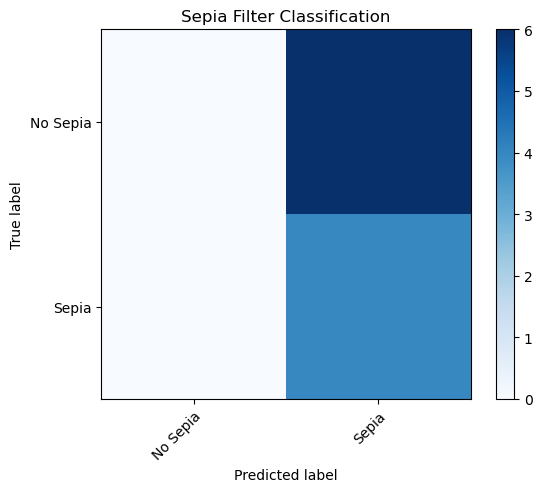

Accuracy: 0.5
Precision: 0.4444444444444444
Recall: 1.0


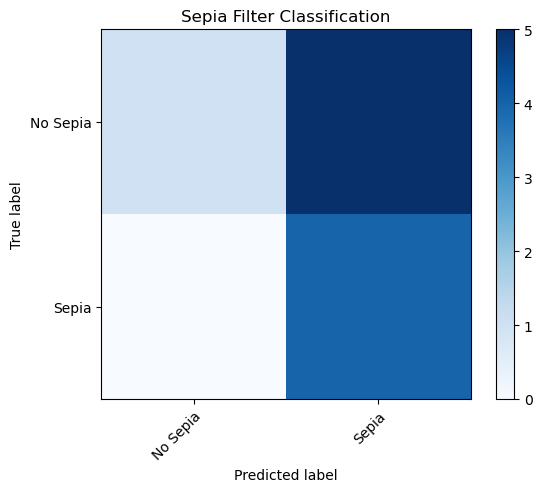

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


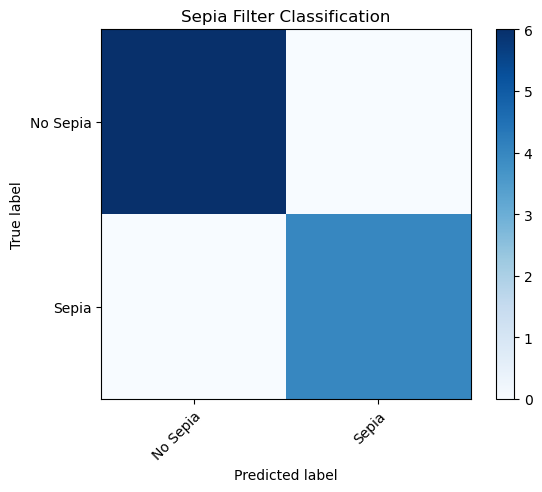

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


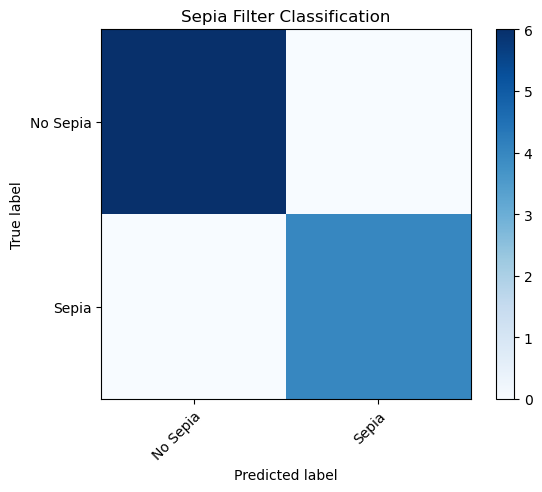

In [7]:
run_experiment((50,), 0.1, 'sgd', 500)
run_experiment((50,), 0.01, 'adam', 300)
run_experiment((50, 30), 0.001, 'adam', 500)
run_experiment((100, 50), 0.001, 'adam', 500)

In [11]:
import numpy as np

class MyMLPClassifier:
    def __init__(self, hidden_layer_sizes=(100,), activation='relu', alpha=0.0001,
                 learning_rate_init=0.001, max_iter=200, random_state=None, verbose=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.random_state = random_state
        self.verbose = verbose
        self.weights = []
        self.biases = []

    def _initialize_weights_and_biases(self, input_size, output_size):
        #initializez legaturile dintre neuroni si biaseuri
        #layer_sizes va contine numarul de neuroni din fiecare layer
        layer_sizes = [input_size] + list(self.hidden_layer_sizes) + [output_size]
        for i in range(1, len(layer_sizes)):
            self.weights.append(np.random.randn(layer_sizes[i - 1], layer_sizes[i]) * 0.01)
            self.biases.append(np.zeros((1, layer_sizes[i])))

    #functia de activare aplicata dupa fiecare strat
    def _activation_function(self, z):
        if self.activation == 'relu':
            return np.maximum(0, z)
        elif self.activation == 'tanh':
            return np.tanh(z)
        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-z))
        else:
            raise ValueError("Invalid activation function. Supported activations: 'relu', 'tanh', 'sigmoid'.")

    #derivata folosita pentru invatare
    def _derivative_activation_function(self, z):
        if self.activation == 'relu':
            return (z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(z) ** 2
        elif self.activation == 'sigmoid':
            return np.exp(-z) / (1 + np.exp(-z)) ** 2
        else:
            raise ValueError("Invalid activation function. Supported activations: 'relu', 'tanh', 'sigmoid'.")

    def fit(self, X, y):
        self._initialize_weights_and_biases(X.shape[1], 1)

        y = np.reshape(y, (-1, 1))

        for i in range(self.max_iter):
            #forward propagation
            a = [X]#va stoca activarile fiecarui strat
            #parcurgem straturile
            for weight, bias in zip(self.weights[:-1], self.biases[:-1]):
            #produsul scalar dintre activarile stratului anterior si greutatile dintre stratul anterior si cel curent + bias 
                z = np.dot(a[-1], weight) + bias
                a.append(self._activation_function(z))

            # output layer with sigmoid (binary classification)
            z = np.dot(a[-1], self.weights[-1]) + self.biases[-1]
            a_out = 1 / (1 + np.exp(-z))  # sigmoid
            a.append(a_out)

            #loss
            if self.verbose and i % 10 == 0:
                loss = np.mean(np.square(y - a[-1]))
                print(f"Epoch {i}, Loss: {loss}")
                
            # backward propagation
            delta = a_out - y
            grads_w = []
            grads_b = []

            for l in reversed(range(len(self.weights))):
                a_prev = a[l]
                dw = np.dot(a_prev.T, delta) / X.shape[0]
                db = np.mean(delta, axis=0, keepdims=True)

                grads_w.insert(0, dw)
                grads_b.insert(0, db)

                if l > 0:
                    delta = np.dot(delta, self.weights[l].T) * self._derivative_activation_function(a[l])

            # update weights and biases
            for l in range(len(self.weights)):
                self.weights[l] -= self.learning_rate_init * grads_w[l]
                self.biases[l] -= self.learning_rate_init * grads_b[l]

    def predict(self, X):
        #forward propagation
        a = X
        for weight, bias in zip(self.weights[:-1], self.biases[:-1]):
            z = np.dot(a, weight) + bias
            a = self._activation_function(z)

        #output layer with sigmoid (binary classification)
        output = 1 / (1 + np.exp(-np.dot(a, self.weights[-1]) - self.biases[-1]))
        return (output >= 0.5).astype(int) 


Epoch 0, Loss: 0.24984628879400517
Epoch 10, Loss: 0.24633921328135971
Epoch 20, Loss: 0.24149434663464894
Epoch 30, Loss: 0.2332182213115926
Epoch 40, Loss: 0.2187942048239256
Epoch 50, Loss: 0.19563973071131452
Epoch 60, Loss: 0.16332827282100018
Epoch 70, Loss: 0.1265986803009634
Epoch 80, Loss: 0.09338899212091738
Epoch 90, Loss: 0.06811802360005412
Epoch 100, Loss: 0.050526152084267396
Epoch 110, Loss: 0.038378987765221216
Epoch 120, Loss: 0.029841550525292082
Epoch 130, Loss: 0.023665485689251236
Epoch 140, Loss: 0.01913805805597743
Epoch 150, Loss: 0.015743318535704383
Epoch 160, Loss: 0.013162485089945362
Epoch 170, Loss: 0.011160743058027039
Epoch 180, Loss: 0.009583569087219121
Epoch 190, Loss: 0.008333370119257383
Epoch 200, Loss: 0.007314828874248008
Epoch 210, Loss: 0.0064868644669325475
Epoch 220, Loss: 0.005802288754477289
Epoch 230, Loss: 0.005230817418325139
Epoch 240, Loss: 0.0047492602703906855
Epoch 250, Loss: 0.004338859485640062
Epoch 260, Loss: 0.0039871442719634

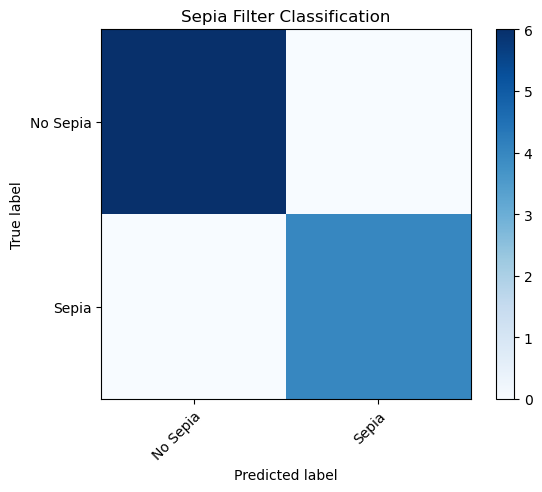

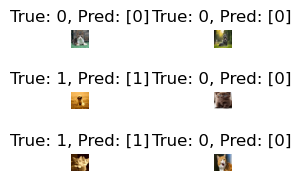

In [12]:
ANN=MyMLPClassifier(hidden_layer_sizes=(50,), activation='relu', max_iter=500, learning_rate_init=0.01, verbose=True)

ANN.fit(train_inputs,train_outputs)
predicted_labels=ANN.predict(test_inputs)

acc, prec, rec, cm = eval_classification(test_outputs, predicted_labels)
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)

plot_confusion_matrix(cm, ['No Sepia', 'Sepia'], "Sepia Filter Classification")

n = 3
m = 2
fig, axes = plt.subplots(n, m, figsize=(3, 2))
fig.tight_layout()
for i in range(n):
    for j in range(m):
        idx = i * m + j
        if idx >= len(test_inputs):
            break
        img = test_inputs[idx].reshape(images.shape[1], images.shape[2], images.shape[3])
        axes[i][j].imshow(img)
        title = f"True: {test_outputs[idx]}, Pred: {predicted_labels[idx]}"
        font = 'bold' if test_outputs[idx] != predicted_labels[idx] else 'normal'
        axes[i][j].set_title(title, fontweight=font)
        axes[i][j].axis('off')
plt.show()

In [55]:
import numpy as np

class MyCNNClassifier:
    def __init__(self, conv_layer_configs=[(32, 3, 3)], pool_size=(2, 2), hidden_layer_sizes=(100,),
                 activation='relu', alpha=0.0001, learning_rate_init=0.001, max_iter=200, random_state=None,
                 verbose=False):
        self.conv_layer_configs = conv_layer_configs #lista de tuple care specifica nr de filtre si inaltimea si latimea fiecarui filtru 
        self.pool_size = pool_size 
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.random_state = random_state
        self.verbose = verbose
        self.weights = []
        self.biases = []
        self.filters = []  
        self.pooling_indices = []  

    def _initialize_weights_and_biases(self, input_shape, output_size):
        
        current_input_channels = input_shape[2] 
        for filters, kernel_height, kernel_width in self.conv_layer_configs:
            filter_shape = (filters, kernel_height, kernel_width, current_input_channels)
            #initializez fltrele cu valori mici random
            self.filters.append(np.random.randn(*filter_shape) * 0.01)
            current_input_channels = filters 
            
        #calculez dimensiunea de intrare pentru layer
        input_size = current_input_channels * (input_shape[0] // 2) * (input_shape[1] // 2) 
        #initializez weights si biases pt layere
        layer_sizes = [input_size] + list(self.hidden_layer_sizes) + [output_size]
        for i in range(1, len(layer_sizes)):
            self.weights.append(np.random.randn(layer_sizes[i - 1], layer_sizes[i]) * 0.01)
            self.biases.append(np.zeros((1, layer_sizes[i])))

    #functia de activare
    def _activation_function(self, z):
        if self.activation == 'relu':
            return np.maximum(0, z)
        elif self.activation == 'tanh':
            return np.tanh(z)
        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-z))
        else:
            raise ValueError("Invalid activation function. Supported activations: 'relu', 'tanh', 'sigmoid'.")

    #derivata functiei de activare
    def _derivative_activation_function(self, z):
        if self.activation == 'relu':
            return np.where(z > 0, 1, 0)
        elif self.activation == 'tanh':
            return 1 - np.tanh(z) ** 2
        elif self.activation == 'sigmoid':
            return np.exp(-z) / (1 + np.exp(-z)) ** 2
        else:
            raise ValueError("Invalid activation function. Supported activations: 'relu', 'tanh', 'sigmoid'.")

    #aplica fiecare filtru peste imagine
    def _convolution(self, X, filters):
        #extrag dimensiunile
        f_height, f_width, f_channels = filters.shape[1], filters.shape[2], filters.shape[3]
        X_height, X_width, X_channels = X.shape
        #calculez dimensiunile de output
        output_height = X_height - f_height + 1
        output_width = X_width - f_width + 1
        output = np.zeros((output_height, output_width, filters.shape[0]))

        for i in range(output_height):
            for j in range(output_width):
                #selectez o regiune din imaginea originala
                region = X[i:i + f_height, j:j + f_width, :]
                #pentru fiecare filtru aplic produsul Hadamard
                for f in range(filters.shape[0]):
                    output[i, j, f] = np.sum(region * filters[f]) 
        return output

    def _max_pool(self, X):
        #impart iaginea in ferestre si returnez valoarea maxima din fiecare fereastra
        pool_height, pool_width = self.pool_size
        X_height, X_width, X_channels = X.shape
        output_height = X_height // pool_height
        output_width = X_width // pool_width
        output = np.zeros((output_height, output_width, X_channels))

        for i in range(output_height):
            for j in range(output_width):
                for c in range(X_channels):
                    region = X[i * pool_height: (i + 1) * pool_height, j * pool_width: (j + 1) * pool_width, c]
                    output[i, j, c] = np.max(region)
        return output

    def fit(self, X, y):
        self._initialize_weights_and_biases(X.shape, 1)
        y = np.reshape(y, (-1, 1))

        for i in range(self.max_iter):
            # Forward propagation
            a = [X]
            for filters in self.filters:
                #aplic convultion si max pool pentru fiecare fltru
                a.append(self._convolution(a[-1], filters))
                a.append(self._max_pool(a[-1]))
            
            #transform matricea 3D in vector
            flattened = a[-1].flatten().reshape(1, -1)
            a.append(flattened)

            #trec activarile prin straturile ascunse
            for weight, bias in zip(self.weights, self.biases):
                z = np.dot(a[-1], weight) + bias
                a.append(self._activation_function(z))

            # Backward propagation
            #calculez gradientele si actualizez weights si biases
            dz = a[-1] - y
            for j in range(len(self.weights) - 1, -1, -1):
                dw = (1 / X.shape[0]) * np.dot(a[j].T, dz)
                db = (1 / X.shape[0]) * np.sum(dz, axis=0, keepdims=True)
                #propagarea erorii
                dz = np.dot(dz, self.weights[j].T) * self._derivative_activation_function(a[j])
                self.weights[j] -= self.learning_rate_init * dw
                self.biases[j] -= self.learning_rate_init * db

            if self.verbose and i % 10 == 0:
                loss = np.mean(np.square(y - a[-1]))
                print(f"Epoch {i}, Loss: {loss}")

    def predict(self, X):
        a = X
        for filters in self.filters:
            a = self._convolution(a, filters)
            a = self._max_pool(a)

        flattened = a.flatten().reshape(1, -1)
        for weight, bias in zip(self.weights, self.biases):
            z = np.dot(flattened, weight) + bias
            a = self._activation_function(z)

        binary_output = np.where(a >= 0.5, 1, 0)
        return binary_output


In [25]:
pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [59]:
import cv2
def normalize(images):
    images_flatten = np.array(images, dtype=np.float32)
    images_flatten /= 255.0  
    return images_flatten
def resize_images(images, target_size=(32, 32)):
    resized_images = []
    for img in images:
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        resized_img = cv2.resize(img, target_size)
        resized_images.append(resized_img)
    return np.array(resized_images)

def prepare_dataset(folder_no_filter, folder_sepia, target_size=(32, 32)):
    no_filter_images, no_filter_labels = load_images_from_folder(folder_no_filter, 0)
    sepia_images, sepia_labels = load_images_from_folder(folder_sepia, 1)

    images = no_filter_images + sepia_images
    labels = no_filter_labels + sepia_labels

    images = resize_images(images, target_size)
    images = np.array(images)
    labels = np.array(labels)

    indices = np.random.permutation(len(images))
    images = images[indices]
    labels = labels[indices]

    return images, labels

Error loading image: simple_images/.ipynb_checkpoints
Iteration 0, Loss: 0.4998986424983535
Iteration 10, Loss: 0.4412128292810705
Iteration 20, Loss: 0.3796050890880445
Iteration 30, Loss: 0.3381024819317339
Iteration 40, Loss: 0.3100626604064646
Iteration 50, Loss: 0.2910381440626338
Iteration 60, Loss: 0.27805105565554183
Iteration 70, Loss: 0.2691075108881384
Iteration 80, Loss: 0.2628724714260427
Iteration 90, Loss: 0.25845203828961727
Iteration 100, Loss: 0.2552476834189227
Iteration 110, Loss: 0.25285864842552697
Iteration 120, Loss: 0.25101659434259294
Iteration 130, Loss: 0.2495418454716475
Iteration 140, Loss: 0.2483140918519206
Iteration 150, Loss: 0.24725277269803705
Iteration 160, Loss: 0.2463039418623844
Iteration 170, Loss: 0.24543147342569585
Iteration 180, Loss: 0.2446111732797986
Iteration 190, Loss: 0.24382683645713712
Iteration 200, Loss: 0.24306760726164214
Iteration 210, Loss: 0.24232621170804994
Iteration 220, Loss: 0.24159777402726695
Iteration 230, Loss: 0.2408

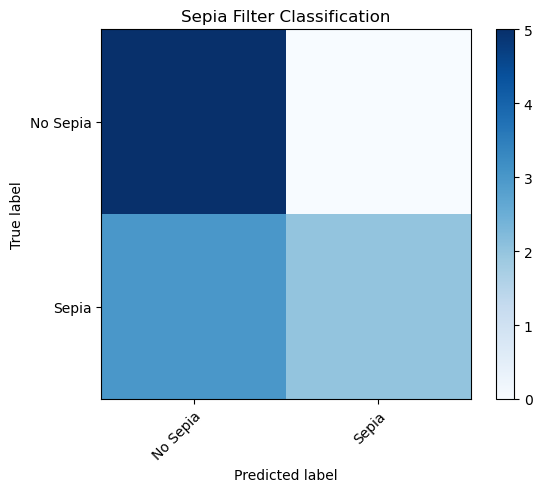

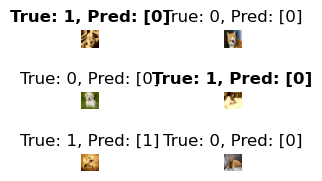

In [62]:
folder_no_filter = 'simple_images'
folder_sepia = 'sepia_images'

images, labels = prepare_dataset(folder_no_filter, folder_sepia)
images_flatten = normalize(images)
train_inputs, train_outputs, test_inputs, test_outputs = split_data(images_flatten, labels)

CNN=MyCNN(kernel_size=(3, 3), pool_size=(2, 2), num_filters=8, hidden_layer_sizes=(64,), max_iter=300, learning_rate_init=0.01, verbose=True)

CNN.fit(train_inputs,train_outputs)
predicted_labels=CNN.predict(test_inputs)

acc, prec, rec, cm = eval_classification(test_outputs, predicted_labels)
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)

plot_confusion_matrix(cm, ['No Sepia', 'Sepia'], "Sepia Filter Classification")

n = 3
m = 2
fig, axes = plt.subplots(n, m, figsize=(3, 2))
fig.tight_layout()
for i in range(n):
    for j in range(m):
        idx = i * m + j
        if idx >= len(test_inputs):
            break
        img = test_inputs[idx].reshape(images.shape[1], images.shape[2], images.shape[3])
        axes[i][j].imshow(img)
        title = f"True: {test_outputs[idx]}, Pred: {predicted_labels[idx]}"
        font = 'bold' if test_outputs[idx] != predicted_labels[idx] else 'normal'
        axes[i][j].set_title(title, fontweight=font)
        axes[i][j].axis('off')
plt.show()